# Process GM12878 ENCODE DNase data

## Set up wandb

In [2]:
import wandb
import os
import numpy as np
import pandas as pd
import torch

import grelu.io.bed
import grelu.data.preprocess
import grelu.visualize

%matplotlib inline
wandb.login(host='https://api.wandb.ai')
project_name='GM12878_dnase'

run = wandb.init(
    entity='grelu', project=project_name, job_type='preprocessing', name='prep',
    settings=wandb.Settings(
        program_relpath='1_process_GM12878_data.ipynb',
        program_abspath='/code/github/gReLU-applications/VEP_benchmark/1_process_GM12878_data.ipynb')
)

## Load peaks

In [3]:
peak_file = "ENCFF588OCA.bed.gz" # Downloaded from encode

## Merge peaks

In [15]:
!zcat ENCFF588OCA.bed.gz | awk -v OFS='\t' '{print $1,$2+$10-250,$2+$10+250}' | bedtools sort | bedtools merge | awk -v OFS='\t' '{mid=int(($2+$3)/2); print $1,$2,$3,".",".",".",".",".",".",mid-$2}'  > ENCFF588OCA.summit.500bp.narrowPeak

## Load merged peaks

In [16]:
peaks = grelu.io.bed.read_narrowpeak('ENCFF588OCA.summit.500bp.narrowPeak')

In [17]:
len(peaks)

230421

## Extend to sequence length

In [19]:
peaks = grelu.data.preprocess.extend_from_coord(
    peaks,
    seq_len=2114,
    center_col="summit"
)
print(len(peaks))
peaks.tail(3)

230421


,chrom,start,end
230418,chrY,56838273,56840387
230419,chrY,56839860,56841974
230420,chrY,56849042,56851156


## Filter peaks

In [20]:
# Filter peaks outside autosomes
peaks = grelu.data.preprocess.filter_chromosomes(peaks, 'autosomes')

Keeping 223259 intervals


In [21]:
# Filter peaks close to blacklist regions
peaks = grelu.data.preprocess.filter_blacklist(
    peaks,
    genome='hg38',
    window=50 # Remove peaks if they are within 50 bp of a blacklist region
)

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Keeping 222151 intervals


## Get GC matched negative intervals

In [23]:
negatives = grelu.data.preprocess.get_gc_matched_intervals(
    peaks,
    binwidth=0.05, # resolution of measuring GC content
    genome='hg38',
    chroms="autosomes", # negative regions will also be chosen from autosomes
    blacklist='hg38', # negative regions overlapping the blacklist will be dropped
)
negatives.head(3)

Extracting matching intervals
Filtering blacklist
Keeping 212904 intervals


,chrom,start,end
37166,chr1,803320,805434
188961,chr1,820232,822346
111360,chr1,822346,824460


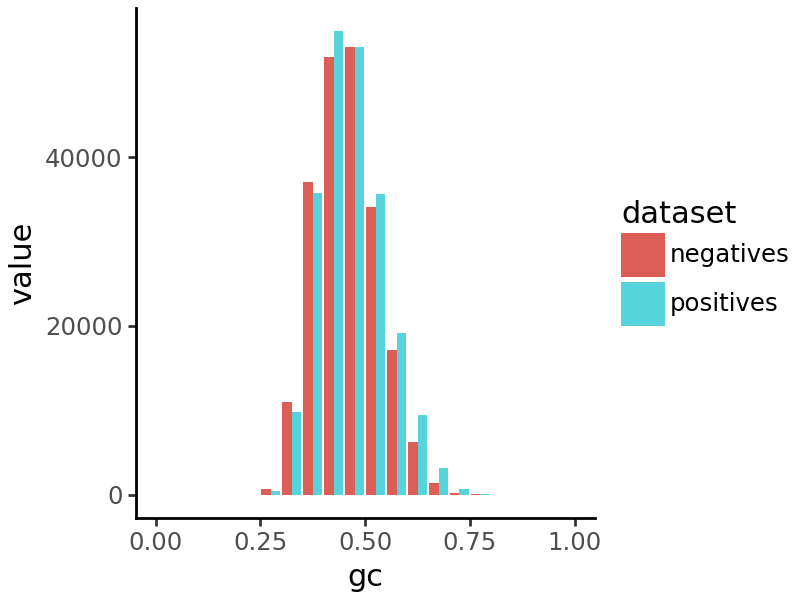

In [24]:
grelu.visualize.plot_gc_match(
    positives=peaks, negatives=negatives, binwidth=0.05, genome="hg38"
)

## Combine all intervals

In [25]:
regions = pd.concat([peaks, negatives])
regions.shape

(435055, 3)

## Save

In [26]:
regions.to_csv('intervals.bed', sep='\t', header=False, index=False)

In [27]:
artifact = wandb.Artifact('dataset', type='dataset')
artifact.add_file('intervals.bed')
run.log_artifact(artifact)

<Artifact dataset>

In [28]:
run.finish()